In [4]:
# ─── Importaciones ───────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configuración visual
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [9]:
# Carga el dataset
df = pd.read_csv("Salary_dataset.csv")

# Vistazo inicial
print("Primeras 5 filas del dataset:")
df.head()

Primeras 5 filas del dataset:


,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [10]:
# Información general del dataset
df.shape

(30, 3)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes


In [12]:
df.isnull().sum()

Unnamed: 0         0
YearsExperience    0
Salary             0
dtype: int64

In [13]:
# Estadísticas descriptivas
print("\nEstadísticas descriptivas:")
df.describe().round(2)


Estadísticas descriptivas:


,Unnamed: 0,YearsExperience,Salary
count,30.00,30.00,30.00
mean,14.50,5.41,76004.00
std,8.80,2.84,27414.43
min,0.00,1.20,37732.00
25%,7.25,3.30,56721.75
50%,14.50,4.80,65238.00
75%,21.75,7.80,100545.75
max,29.00,10.60,122392.00


In [14]:
# ─── 2.1 Verificar valores nulos ─────────────────────────────────────────────
print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
Unnamed: 0         0
YearsExperience    0
Salary             0
dtype: int64


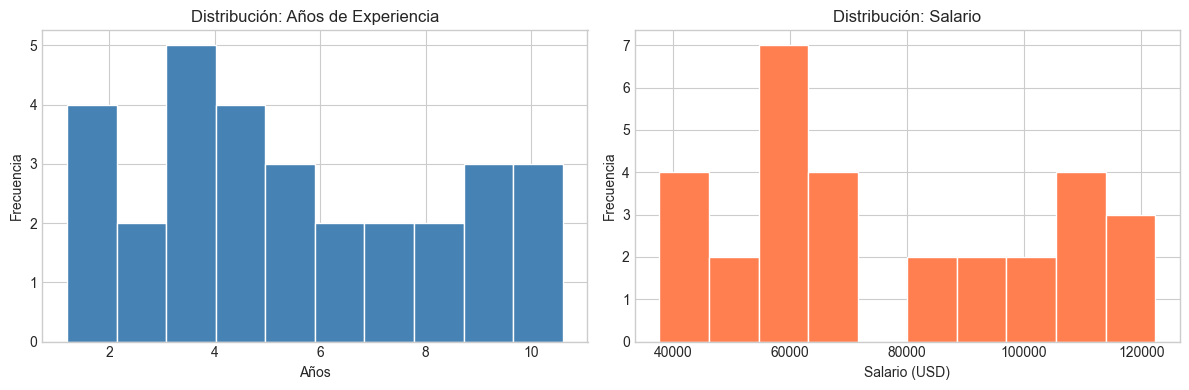

In [15]:
# ─── 2.2 Subplot con 2 histogramas ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['YearsExperience'], bins=10, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución: Años de Experiencia')
axes[0].set_xlabel('Años')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(df['Salary'], bins=10, color='coral', edgecolor='white')
axes[1].set_title('Distribución: Salario')
axes[1].set_xlabel('Salario (USD)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

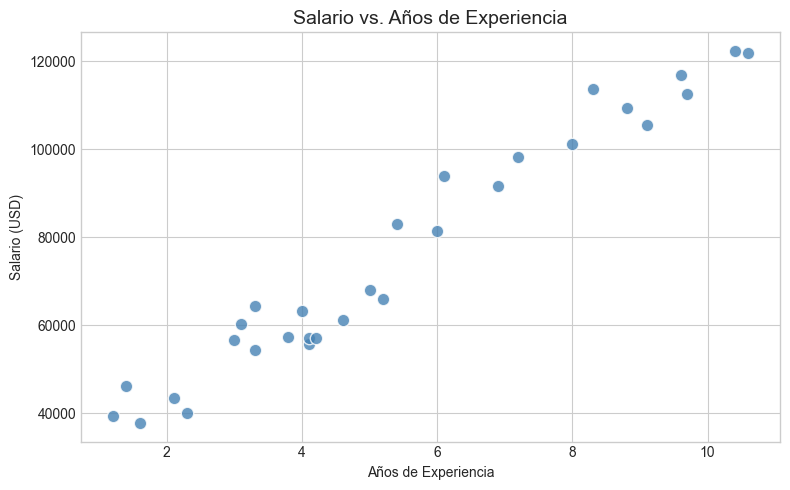

In [16]:
# ─── 2.3 scatter plot de YearsExperience (eje X) vs Salary (eje Y) ───────────────────────────────
plt.figure(figsize=(8, 5))
plt.scatter(df['YearsExperience'], df['Salary'], color='steelblue', s=80, alpha=0.8, edgecolors='white')
plt.title('Salario vs. Años de Experiencia', fontsize=14)
plt.xlabel('Años de Experiencia')
plt.ylabel('Salario (USD)')
plt.tight_layout()
plt.show()

In [17]:
# ─── 2.4 Correlación de Pearson ──────────────────────────────────────────────
correlacion = df['YearsExperience'].corr(df['Salary'])
print(f" Correlación de Pearson (X, y): {correlacion:.4f}")

 Correlación de Pearson (X, y): 0.9782


In [18]:
# ─── 3.1 Separar variables ───────────────────────────────────────────────────
# X: variable independiente (entrada)
# y: variable dependiente (salida a predecir)

X = df[['YearsExperience']]   # DataFrame 2D — sklearn lo requiere así
y = df['Salary']               # Series 1D

print(f" Forma de X: {X.shape}")
print(f" Forma de y: {y.shape}")

 Forma de X: (30, 1)
 Forma de y: (30,)


In [19]:
# ─── 3.2 División en conjuntos de entrenamiento y prueba ──────────────────────
# 80% para entrenar, 20% para evaluar
# random_state=42 garantiza reproducibilidad (siempre el mismo split)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f" Datos de entrenamiento: {X_train.shape[0]} muestras")
print(f" Datos de prueba:        {X_test.shape[0]} muestras")

 Datos de entrenamiento: 24 muestras
 Datos de prueba:        6 muestras


In [20]:
# ─── 4.1 Crear e instanciar el modelo ────────────────────────────────────────
modelo = LinearRegression()

# El método .fit() encuentra los valores óptimos de β₀ y β₁
modelo.fit(X_train, y_train)

print(" Modelo entrenado exitosamente")
print("─" * 40)
print(f" Intercepto  (β₀): {modelo.intercept_:,.2f}")
print(f" Pendiente   (β₁): {modelo.coef_[0]:,.2f}")

 Modelo entrenado exitosamente
────────────────────────────────────────
 Intercepto  (β₀): 24,380.20
 Pendiente   (β₁): 9,423.82


c:\Users\vdcm1\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


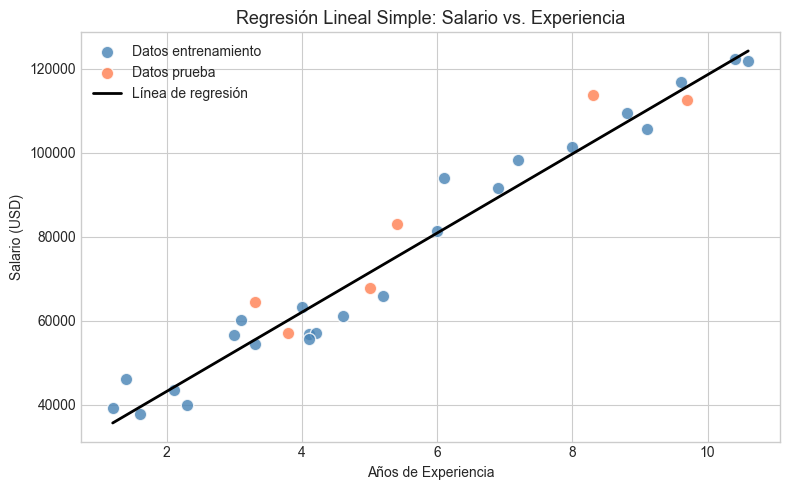

In [21]:
# ─── 4.3 Visualizar la línea de regresión con un scatter plot ────────────────────────────────────
plt.figure(figsize=(8, 5))

# Datos de entrenamiento
plt.scatter(X_train, y_train, color='steelblue', s=80, alpha=0.8,
            edgecolors='white', label='Datos entrenamiento')
# Datos de prueba
plt.scatter(X_test, y_test, color='coral', s=80, alpha=0.8,
            edgecolors='white', label='Datos prueba')

# Línea de regresión
X_linea = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
plt.plot(X_linea, modelo.predict(X_linea), color='black', linewidth=2,
         label='Línea de regresión')

plt.title('Regresión Lineal Simple: Salario vs. Experiencia', fontsize=13)
plt.xlabel('Años de Experiencia')
plt.ylabel('Salario (USD)')
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
# ─── 5.1 Generar predicciones sobre datos de prueba ──────────────────────────
y_pred = modelo.predict(X_test)

# ─── 5.2 Tabla comparativa: valores reales vs predichos ──────────────────────
comparacion = pd.DataFrame({
    'Años_Exp': X_test['YearsExperience'].values,
    'Salario_Real': y_test.values,
    'Salario_Predicho': y_pred.round(2),
    'Error': (y_test.values - y_pred).round(2)
})
print("📋 Comparación Real vs Predicho:")
print(comparacion.to_string(index=False))

📋 Comparación Real vs Predicho:
 Años_Exp  Salario_Real  Salario_Predicho    Error
      9.7      112636.0         115791.21 -3155.21
      5.0       67939.0          71499.28 -3560.28
      8.3      113813.0         102597.87 11215.13
      5.4       83089.0          75268.80  7820.20
      3.3       64446.0          55478.79  8967.21
      3.8       57190.0          60190.70 -3000.70


In [26]:
# ─── 5.3 Calcular métricas de evaluación ─────────────────────────────────────
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print("=" * 45)
print("MÉTRICAS DE EVALUACIÓN")
print("=" * 45)
print(f"  MAE  (Error Absoluto Medio):    ${mae:>12,.2f}")
print(f"  MSE  (Error Cuadrático Medio):  ${mse:>12,.2f}")
print(f"  RMSE (Raíz Error Cuadrático):   ${rmse:>12,.2f}")
print(f"  R²   (Coeficiente Determinación): {r2:>10.4f}")
print("=" * 45)

MÉTRICAS DE EVALUACIÓN
  MAE  (Error Absoluto Medio):    $    6,286.45
  MSE  (Error Cuadrático Medio):  $49,830,096.86
  RMSE (Raíz Error Cuadrático):   $    7,059.04
  R²   (Coeficiente Determinación):     0.9024


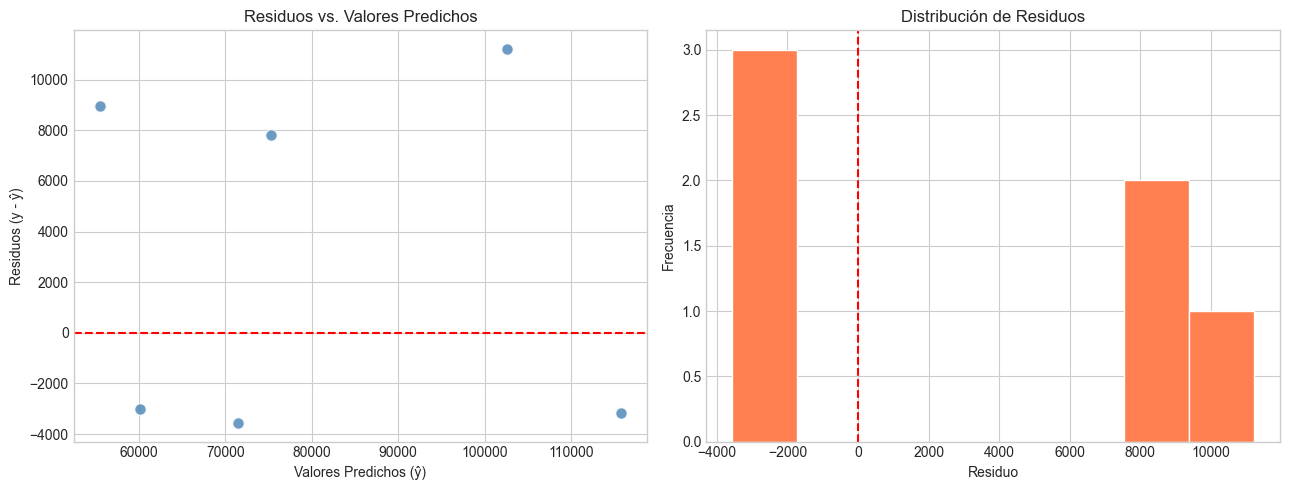

In [27]:
residuos = y_test.values - y_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ─── 6.1 Residuos vs Valores Predichos ───────────────────────────────────────
axes[0].scatter(y_pred, residuos, color='steelblue', s=70, alpha=0.8, edgecolors='white')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title('Residuos vs. Valores Predichos')
axes[0].set_xlabel('Valores Predichos (ŷ)')
axes[0].set_ylabel('Residuos (y - ŷ)')

# ─── 6.2 Distribución de residuos ────────────────────────────────────────────
axes[1].hist(residuos, bins=8, color='coral', edgecolor='white')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Distribución de Residuos')
axes[1].set_xlabel('Residuo')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

In [28]:
# ─── Estrategia 1: Revisar si hay outliers que afectan el modelo ─────────────
# Identificar predicciones con error > 2 desviaciones estándar
umbral = 2 * residuos.std()
outliers_idx = np.where(np.abs(residuos) > umbral)[0]

print(f"  Predicciones con error grande (>{umbral:.0f} USD):")
if len(outliers_idx) > 0:
    print(comparacion.iloc[outliers_idx])
else:
    print("   No se detectaron outliers significativos")

  Predicciones con error grande (>12734 USD):
   No se detectaron outliers significativos


In [29]:
# ─── Estrategia 2: Evaluar también sobre datos de entrenamiento ──────────────
# Si R²_train >> R²_test → hay overfitting (pero en regresión lineal simple es poco probable)
y_pred_train = modelo.predict(X_train)
r2_train = r2_score(y_train, y_pred_train)
r2_test  = r2_score(y_test, y_pred)

print(f"R² entrenamiento: {r2_train:.4f}")
print(f"R² prueba:        {r2_test:.4f}")
print(f"Diferencia:       {abs(r2_train - r2_test):.4f}")

if abs(r2_train - r2_test) > 0.10:
    print("  Posible overfitting — gran diferencia entre entrenamiento y prueba")
else:
    print(" Modelo generaliza bien — diferencia pequeña entre conjuntos")

R² entrenamiento: 0.9645
R² prueba:        0.9024
Diferencia:       0.0621
 Modelo generaliza bien — diferencia pequeña entre conjuntos


In [30]:
# ─── Estrategia 2: Evaluar también sobre datos de entrenamiento ──────────────
# Si R²_train >> R²_test → hay overfitting (pero en regresión lineal simple es poco probable)
y_pred_train = modelo.predict(X_train)
r2_train = r2_score(y_train, y_pred_train)
r2_test  = r2_score(y_test, y_pred)

print(f"R² entrenamiento: {r2_train:.4f}")
print(f"R² prueba:        {r2_test:.4f}")
print(f"Diferencia:       {abs(r2_train - r2_test):.4f}")

if abs(r2_train - r2_test) > 0.10:
    print("  Posible overfitting — gran diferencia entre entrenamiento y prueba")
else:
    print(" Modelo generaliza bien — diferencia pequeña entre conjuntos")

R² entrenamiento: 0.9645
R² prueba:        0.9024
Diferencia:       0.0621
 Modelo generaliza bien — diferencia pequeña entre conjuntos


In [31]:
# ─── Estrategia 3: Validación cruzada (K-Fold) ───────────────────────────────
# Más robusto que un único train/test split, especialmente con datasets pequeños
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(LinearRegression(), X, y, cv=5, scoring='r2')

print(" Validación Cruzada (5-Fold):")
print(f"  R² por fold: {cv_scores.round(4)}")
print(f"  R² promedio: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

 Validación Cruzada (5-Fold):
  R² por fold: [ 0.3596 -1.2442  0.2505  0.297   0.0703]
  R² promedio: -0.0534 ± 0.6032


In [32]:
# ─── Predecir el salario para distintos años de experiencia ──────────────────
nuevos_datos = pd.DataFrame({'YearsExperience': [1.5, 5.0, 8.0, 10.0, 12.0]})
predicciones = modelo.predict(nuevos_datos)

print(" Predicciones de salario:")
print("-" * 40)
for exp, sal in zip(nuevos_datos['YearsExperience'], predicciones):
    print(f"  {exp:>5.1f} años de experiencia → ${sal:>10,.2f} USD")

 Predicciones de salario:
----------------------------------------
    1.5 años de experiencia → $ 38,515.92 USD
    5.0 años de experiencia → $ 71,499.28 USD
    8.0 años de experiencia → $ 99,770.72 USD
   10.0 años de experiencia → $118,618.35 USD
   12.0 años de experiencia → $137,465.99 USD


In [33]:
# ─── Resumen completo del modelo ─────────────────────────────────────────────
print("=" * 50)
print("        RESUMEN DEL MODELO")
print("=" * 50)
print(f"\n  Ecuación: Salario = {modelo.intercept_:,.2f} + {modelo.coef_[0]:,.2f} × Años")
print(f"\n  Métricas sobre conjunto de prueba:")
print(f"    • R²   = {r2:.4f}  {' Excelente' if r2 >= 0.90 else ' Mejorable'}")
print(f"    • MAE  = ${mae:,.2f}")
print(f"    • RMSE = ${rmse:,.2f}")
print(f"\n  Validación cruzada (5-Fold):")
print(f"    • R² promedio = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print("=" * 50)

        RESUMEN DEL MODELO

  Ecuación: Salario = 24,380.20 + 9,423.82 × Años

  Métricas sobre conjunto de prueba:
    • R²   = 0.9024   Excelente
    • MAE  = $6,286.45
    • RMSE = $7,059.04

  Validación cruzada (5-Fold):
    • R² promedio = -0.0534 ± 0.6032
